# TME Music Data Analysis Pipeline
This notebook imports modularized functions from `pipeline`, `reporting`, and `plotting` to perform ETL, analysis, and report generation.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
from config import (
    BASE_PATH, 
    TOP_N_SONGS, 
    TOP_N_ALBUMS, 
    OUTPUT_SONG_REPORT_PATH, 
    OUTPUT_ALBUM_REPORT_PATH,
    OUTPUT_SONG_REPORT_PATH_MONTHLY
)
from pipeline import run_etl_pipeline, clean_and_unify_data
from reporting import generate_song_report, generate_album_report, generate_song_report_by_year
import plotting

In [3]:
print(BASE_PATH, '\n', OUTPUT_SONG_REPORT_PATH)

/Users/chu-chun/Mirror/Eva/input/sony_TME/ 
 ../output/TME_Song_Report_for_Sony_all.xlsx


## 1. Run ETL Pipeline
Extract data from all raw TME Excel files, calculate platform-specific click metrics, and clean the dataset.

In [4]:
# Run the ETL pipeline to ingest files
df_raw = run_etl_pipeline(BASE_PATH)

# Clean dates, unify platforms, and standardize metadata names
df_cleaned = clean_and_unify_data(df_raw)
df_cleaned.info()

/opt/anaconda3/envs/uda/lib/python3.10/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/opt/anaconda3/envs/uda/lib/python3.10/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/opt/anaconda3/envs/uda/lib/python3.10/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/opt/anaconda3/envs/uda/lib/python3.10/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/opt/anaconda3/envs/uda/lib/python3.10/site-packages/openpyxl/styles

<class 'pandas.core.frame.DataFrame'>
Index: 2702471 entries, 2200989 to 383436
Data columns (total 12 columns):
 #   Column           Dtype  
---  ------           -----  
 0   YearMonth        object 
 1   Platform         object 
 2   Song             object 
 3   ISRC             object 
 4   Artist           object 
 5   Album            object 
 6   UPC              object 
 7   Revenue          float64
 8   Total_Clicks     float64
 9   source_file      object 
 10  standard_song    object 
 11  standard_artist  object 
dtypes: float64(2), object(10)
memory usage: 268.0+ MB


In [5]:
# 1. 計算標準的 NA/NaN 數量與比例
na_summary = pd.DataFrame({
    'NA 數量': df_cleaned.isna().sum(),
    'NA 比例 (%)': (df_cleaned.isna().mean() * 100).round(2)
})

print("--- 標準 NA / NaN 統計 ---")
display(na_summary.sort_values(by='NA 數量', ascending=False))


# 2. 同時將「空字串 ''」與「字串型的 'nan'」都列入缺失值計算
# 使用 .apply() 逐欄進行字串小寫比對，以避免 DataFrame 沒有 .str 屬性的問題
is_missing = df_cleaned.isna() | (df_cleaned == '') | df_cleaned.astype(str).apply(lambda s: s.str.lower() == 'nan')

missing_summary = pd.DataFrame({
    '缺失值總計 (含空字串/\'nan\')': is_missing.sum(),
    '缺失值比例 (%)': (is_missing.mean() * 100).round(2)
})

print("\n--- 完整缺失值統計 (含空字串與 'nan' 字串) ---")
display(missing_summary.sort_values(by='缺失值總計 (含空字串/\'nan\')', ascending=False))


--- 標準 NA / NaN 統計 ---


,NA 數量,NA 比例 (%)
UPC,2362939,87.44
Album,138889,5.14
Artist,313,0.01
YearMonth,0,0.00
Platform,0,0.00
Song,0,0.00
ISRC,0,0.00
Revenue,0,0.00
Total_Clicks,0,0.00
source_file,0,0.00



--- 完整缺失值統計 (含空字串與 'nan' 字串) ---


,缺失值總計 (含空字串/'nan'),缺失值比例 (%)
UPC,2362939,87.44
Album,138889,5.14
Artist,313,0.01
YearMonth,0,0.00
Platform,0,0.00
Song,0,0.00
ISRC,0,0.00
Revenue,0,0.00
Total_Clicks,0,0.00
source_file,0,0.00


In [6]:
df_cleaned.head()

,YearMonth,Platform,Song,ISRC,Artist,Album,UPC,Revenue,Total_Clicks,source_file,standard_song,standard_artist
2200989,2023-01,UltimateMusic,我的话记得吗,我的话记得吗 - 李森,李森,十二年,NaN,0.0,18.0,爱听收入明细_非凡成果（北京）文化传媒有限公司_202301_0.xlsx,我的话记得吗,李森
2216695,2023-01,KugouKaraoke,黎明并不远,黎明并不远 - 汪家羽,汪家羽,黎明并不远,NaN,0.0,5.0,K歌收入明细_非凡成果（北京）文化传媒有限公司_202301_0.xlsx,黎明并不远,汪家羽
2216696,2023-01,KugouKaraoke,苏打水,苏打水 - 汪家羽,汪家羽,黎明并不远,NaN,0.0,0.0,K歌收入明细_非凡成果（北京）文化传媒有限公司_202301_0.xlsx,苏打水,汪家羽
2216697,2023-01,KugouKaraoke,漩涡,漩涡 - 汪家羽,汪家羽,黎明并不远,NaN,0.0,0.0,K歌收入明细_非凡成果（北京）文化传媒有限公司_202301_0.xlsx,漩涡,汪家羽
2216698,2023-01,KugouKaraoke,满天星,满天星 - 孙奇,孙奇,满天星,NaN,0.0,0.0,K歌收入明细_非凡成果（北京）文化传媒有限公司_202301_0.xlsx,满天星,孙奇


In [7]:
# convert to str
df_cleaned['Artist'] = df_cleaned['Artist'].astype(str)
df_cleaned['Song'] = df_cleaned['Song'].astype(str)
df_cleaned['standard_artist'] = df_cleaned['standard_artist'].astype(str)
df_cleaned['standard_song'] = df_cleaned['standard_song'].astype(str)


## Monthly Revenue Trend
Plot total monthly revenue and show MoM Growth Percentage.

Monthly Revenue and Clicks Summary:


,YearMonth,revenue,clicks,MoM_Growth_Pct
0,2023-01,8.789781e+05,2.266649e+08,N/A
1,2023-02,8.951006e+05,2.233553e+08,1.83%
2,2023-03,9.574739e+05,2.836223e+08,6.97%
3,2023-04,1.085849e+06,3.092225e+08,13.41%
4,2023-05,1.178503e+06,3.547457e+08,8.53%
5,2023-06,1.079765e+06,2.967930e+08,-8.38%
6,2023-07,9.966707e+05,2.939689e+08,-7.70%
7,2023-08,9.788928e+05,2.821807e+08,-1.78%
8,2023-09,1.014140e+06,2.795866e+08,3.60%
9,2023-10,9.981222e+05,2.890954e+08,-1.58%


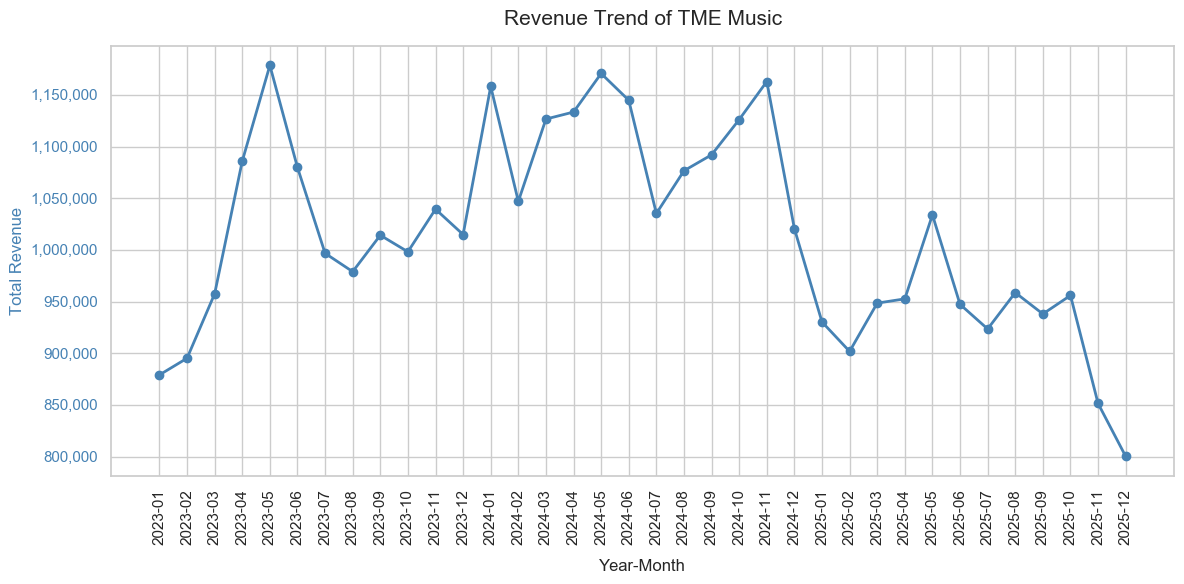

In [8]:
revenue_by_month = (
    df_cleaned.groupby('YearMonth')
    .agg(revenue=('Revenue', 'sum'), clicks=('Total_Clicks', 'sum'))
    .reset_index()
)
revenue_by_month['MoM_Growth_Pct'] = (
    revenue_by_month['revenue']
    .pct_change()
    .apply(lambda x: f"{x:.2%}" if pd.notnull(x) else "N/A")
)

print("Monthly Revenue and Clicks Summary:")
display(revenue_by_month)

# Plot revenue trend line graph
plotting.plot_revenue_trend(revenue_by_month)

## Filter for Specific Analysis Period
Filter the dataset for the designated target period (e.g. 2024-01 to 2026-03).

In [9]:
START_MONTH = "2023-01"
END_MONTH = "2026-06"

df_filtered = df_cleaned[
    (df_cleaned['YearMonth'] >= START_MONTH) & 
    (df_cleaned['YearMonth'] <= END_MONTH)
]
print(f"Filtered dataset from {START_MONTH} to {END_MONTH} contains {len(df_filtered)} rows.")

Filtered dataset from 2023-01 to 2026-06 contains 2702471 rows.


## Top Songs Share & Pie Charts

In [10]:
revenue_by_song = (
    df_filtered
    .groupby(['ISRC'])
    .agg(
        song=('standard_song', 'first'),
        artist=('standard_artist', 'first'),
        revenue=('Revenue', 'sum'),
        clicks=('Total_Clicks', 'sum')
    )
    .reset_index()
)
revenue_by_song = revenue_by_song.sort_values('revenue', ascending=False)

Top 10 songs contribute to 42.04% of total revenue.


,ISRC,song,artist,revenue,clicks,rev_share,click_share
1111,TWC230515112,恶作剧,王蓝茵,4.162906e+06,948810625.0,0.113889,0.122573
1149,TWC230814104,下雨天,南拳妈妈,2.007223e+06,386491232.0,0.054914,0.049929
4650,夏天的风 - 温岚,夏天的风,温岚,1.321365e+06,272103111.0,0.036150,0.035152
1454,TWF710700026,同手同脚,温岚,1.197971e+06,181166850.0,0.032774,0.023404
7525,爱的魔法 - 金莎,爱的魔法,金莎,1.181980e+06,233128085.0,0.032337,0.030117
1104,TWC230515103,遇到,方雅贤,1.181709e+06,255544347.0,0.032329,0.033013
1467,TWF710800006,为你写诗,吴克群,1.133648e+06,216619666.0,0.031014,0.027984
8618,该死的温柔 - 马天宇,该死的温柔,马天宇,1.096820e+06,242578444.0,0.030007,0.031338
7500,爱的就是你 - 刘佳,爱的就是你,刘佳,1.048762e+06,185521233.0,0.028692,0.023967
2047,TWI431603105,飘洋过海来看你,刘明湘,1.033866e+06,176743275.0,0.028284,0.022833


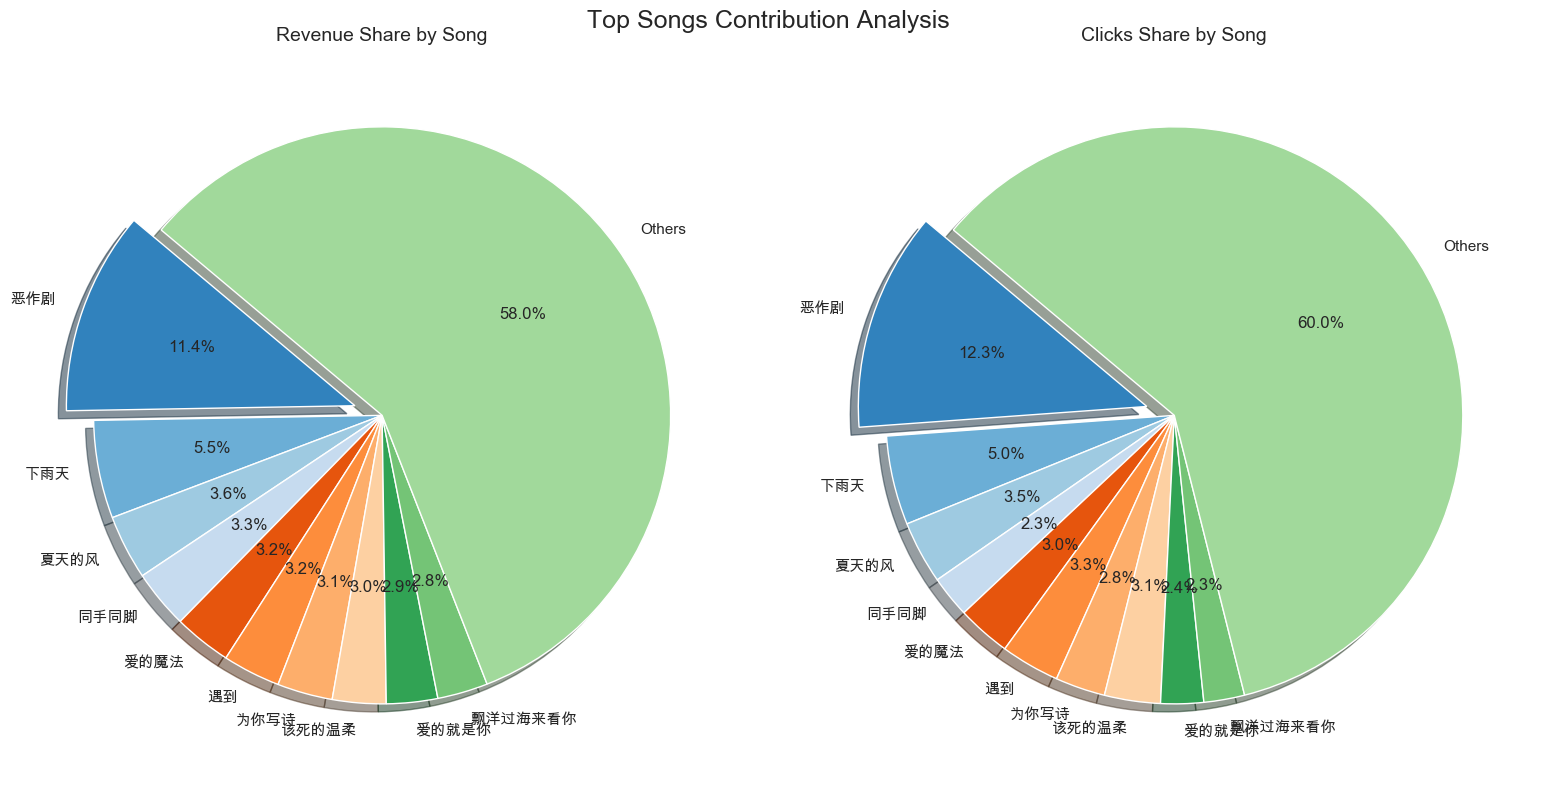

In [11]:
total_rev = revenue_by_song['revenue'].sum()
total_clicks = revenue_by_song['clicks'].sum()

revenue_by_song_top = revenue_by_song.head(TOP_N_SONGS).copy()
revenue_by_song_top['rev_share'] = revenue_by_song_top['revenue'] / total_rev
revenue_by_song_top['click_share'] = revenue_by_song_top['clicks'] / total_clicks
top_song_list = revenue_by_song_top['ISRC'].tolist()

print(f"Top {TOP_N_SONGS} songs contribute to {revenue_by_song_top['rev_share'].sum():.2%} of total revenue.")
display(revenue_by_song_top)

# Side-by-side pie charts for revenue & clicks contribution
top_song_detail = revenue_by_song.head(TOP_N_SONGS).copy()[['song', 'revenue', 'clicks']]
other_songs_rev = revenue_by_song[~revenue_by_song['ISRC'].isin(top_song_list)]['revenue'].sum()
other_songs_clicks = revenue_by_song[~revenue_by_song['ISRC'].isin(top_song_list)]['clicks'].sum()

others_row = pd.DataFrame([{
    'song': 'Others',
    'revenue': other_songs_rev,
    'clicks': other_songs_clicks
}])

df_pie = pd.concat([top_song_detail, others_row], ignore_index=True)
plotting.plot_pie_charts(df_pie)

## Generate Song Report
Aggregates, pivots, and exports monthly metrics to Excel.

In [12]:
song_final = generate_song_report(df_filtered, OUTPUT_SONG_REPORT_PATH_MONTHLY)

Song report exported successfully to: ../output/TME_Song_Report_Monthly_for_Sony_all.xlsx


In [13]:
song_final.head()

,ISRC,song,artist,UPC,album,total_click,total_revenue,2023-01_clicks,2023-01_revenue,2023-02_clicks,...,2025-08_clicks,2025-08_revenue,2025-09_clicks,2025-09_revenue,2025-10_clicks,2025-10_revenue,2025-11_clicks,2025-11_revenue,2025-12_clicks,2025-12_revenue
0,TWC230515112,恶作剧,王蓝茵,UPC-828767536125,恶作剧之吻 电视剧原声带,948810625.0,4.162906e+06,15577512.0,66101.000420,13585073.0,...,19551085.0,92520.505206,16911594.0,87563.060316,17755431.0,92547.295120,16920393.0,83858.981614,17712746.0,82249.244169
1,TWC230515103,遇到,方雅贤,UPC-828767536125,恶作剧之吻 电视剧原声带,255544347.0,1.181709e+06,7138515.0,28689.629770,7510041.0,...,6571331.0,30612.444688,5837432.0,30271.158690,5924374.0,30373.683705,5511271.0,27406.163085,5858819.0,27297.963643
2,TWC230107211,屋顶,"温岚,周杰伦",UPC-4710635380335,爱回温,143386080.0,6.526231e+05,3472910.0,16481.733303,3178422.0,...,4143723.0,16510.949614,3965474.0,17809.686885,4171578.0,18400.078671,3854632.0,16165.251385,3788060.0,15529.051369
3,TWI431603105,飘洋过海来看你,刘明湘,UPC-4712505300245,我不要再比了,112755961.0,5.583396e+05,3092937.0,13073.663184,3095409.0,...,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000
4,TWI431603105,漂洋过海来看你,刘明湘,UPC-4712505300245,我不要再比了,63987314.0,4.755269e+05,0.0,0.000000,0.0,...,5120422.0,37735.712816,4843138.0,38841.180025,5586138.0,44015.840637,5349439.0,40290.560442,5532760.0,40257.166800


## Generate Song Report by Year

In [14]:
df_filtered.head()

,YearMonth,Platform,Song,ISRC,Artist,Album,UPC,Revenue,Total_Clicks,source_file,standard_song,standard_artist
2200989,2023-01,UltimateMusic,我的话记得吗,我的话记得吗 - 李森,李森,十二年,NaN,0.0,18.0,爱听收入明细_非凡成果（北京）文化传媒有限公司_202301_0.xlsx,我的话记得吗,李森
2216695,2023-01,KugouKaraoke,黎明并不远,黎明并不远 - 汪家羽,汪家羽,黎明并不远,NaN,0.0,5.0,K歌收入明细_非凡成果（北京）文化传媒有限公司_202301_0.xlsx,黎明并不远,汪家羽
2216696,2023-01,KugouKaraoke,苏打水,苏打水 - 汪家羽,汪家羽,黎明并不远,NaN,0.0,0.0,K歌收入明细_非凡成果（北京）文化传媒有限公司_202301_0.xlsx,苏打水,汪家羽
2216697,2023-01,KugouKaraoke,漩涡,漩涡 - 汪家羽,汪家羽,黎明并不远,NaN,0.0,0.0,K歌收入明细_非凡成果（北京）文化传媒有限公司_202301_0.xlsx,漩涡,汪家羽
2216698,2023-01,KugouKaraoke,满天星,满天星 - 孙奇,孙奇,满天星,NaN,0.0,0.0,K歌收入明细_非凡成果（北京）文化传媒有限公司_202301_0.xlsx,满天星,孙奇


In [15]:
song_final = generate_song_report_by_year(df_filtered, OUTPUT_SONG_REPORT_PATH)
song_final.head()

Yearly song report exported successfully to: ../output/TME_Song_Report_for_Sony_all.xlsx


,ISRC,song,artist,total_click,total_revenue,2023_clicks,2024_clicks,2025_clicks,2023_revenue,2024_revenue,2025_revenue
0,TWC230515112,恶作剧,王蓝茵,948810625.0,4.162906e+06,482431726.0,243939113.0,222439786.0,1.657627e+06,1.420051e+06,1.085227e+06
1,TWC230814104,下雨天,南拳妈妈,386491232.0,2.007223e+06,117752304.0,133845245.0,134893683.0,4.561341e+05,7.588172e+05,7.922722e+05
2,夏天的风 - 温岚,夏天的风,温岚,272103111.0,1.321365e+06,98466144.0,78539618.0,95097349.0,3.723631e+05,4.476324e+05,5.013694e+05
3,TWF710700026,同手同脚,温岚,181166850.0,1.197971e+06,8833065.0,10336639.0,161997146.0,3.428992e+04,5.700604e+04,1.106675e+06
4,爱的魔法 - 金莎,爱的魔法,金莎,233128085.0,1.181980e+06,96302216.0,66281933.0,70543936.0,3.970978e+05,4.360828e+05,3.487995e+05


## One song with multiple singer

In [16]:
# 找出 song_final 裡面有超過一個歌手的歌曲（artist 欄位包含英文逗號 ',' 或中文逗號 '，'）
multi_artist_songs = song_final[song_final['artist'].astype(str).str.contains(',|，', na=False)]
multi_artist_songs = multi_artist_songs[multi_artist_songs['ISRC'].astype(str).str.contains(' - ', na=False)].copy()

# 顯示篩選出的歌曲資料
target_col = ['ISRC','song','artist']
multi_artist_songs = multi_artist_songs[target_col]
multi_artist_songs['song'] = multi_artist_songs['song'].astype(str)
# multi_artist_songs['artist'] = multi_artist_songs['artist'].astype(str)
# multi_artist_songs = multi_artist_songs.sort_values(by=['song', 'artist'], ascending=False)
# multi_artist_songs.to_excel("/Users/chu-chun/Mirror/Eva/output/TME_multiple_singer.xlsx", index=False)

temp = multi_artist_songs.groupby('song').agg(count = ('artist', 'size')).reset_index().sort_values('count', ascending=False)
temp = temp[temp['count']>1]
song_list = temp['song'].tolist()

temp = multi_artist_songs[multi_artist_songs['song'].isin(song_list)]

# sing together
# temp.to_excel("/Users/chu-chun/Mirror/Eva/output/TME_multiple_singer_list.xlsx", index=False)

In [17]:
# 找出一首歌對應的所有歌手
song_artists = song_final.groupby('song')['artist'].nunique()
different_song_names = song_artists[song_artists>1].index.tolist()
result_df = song_final[song_final['song'].isin(different_song_names)]
result_df['song'] = result_df['song'].astype(str)
result_df = result_df.sort_values(by='song')

# exclude songs with ISRC
result_df = result_df[result_df['ISRC'].astype(str).str.contains(' - ', na=False)].copy()
result_df


/var/folders/hg/5j5mzy6x2ps4l676cl2hpt_r0000gn/T/ipykernel_88214/1823252205.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  result_df['song'] = result_df['song'].astype(str)


,ISRC,song,artist,total_click,total_revenue,2023_clicks,2024_clicks,2025_clicks,2023_revenue,2024_revenue,2025_revenue
8513,11号患者 - 刘冠帅,11号患者,刘冠帅,36.0,0.148315,16.0,12.0,8.0,0.017562,0.076637,0.054116
5416,11号患者 - 金硕,11号患者,金硕,863.0,3.007558,483.0,150.0,230.0,1.299199,0.445268,1.263091
7031,333444 - 清源,333444,清源,472.0,0.754119,389.0,57.0,26.0,0.361597,0.279664,0.112858
6423,333444 - 姚雷,333444,姚雷,454.0,1.247240,273.0,144.0,37.0,0.343541,0.707456,0.196243
8187,BADBOY - 2SX组合,Bad Boy,2SX组合,90.0,0.241650,61.0,21.0,8.0,0.059946,0.115598,0.066107
...,...,...,...,...,...,...,...,...,...,...,...
8157,黄色的海 - 佳丽,黄色的海,佳丽,72.0,0.249917,0.0,0.0,72.0,0.000000,0.000000,0.249917
8637,黄色的海 - 小佳丽LJL,黄色的海,小佳丽LJL,120.0,0.120766,120.0,0.0,0.0,0.120766,0.000000,0.000000
9014,黄色的海 - 崽仔吖,黄色的海,崽仔吖,30.0,0.051180,30.0,0.0,0.0,0.051180,0.000000,0.000000
1386,黑白 - 斯琴高丽,黑白,斯琴高丽,75239.0,279.389854,49669.0,18771.0,6799.0,129.904214,109.503357,39.982283


In [18]:
synthetic_isrc = song_final[song_final['ISRC'].astype(str).str.contains(' - ', na=False)].copy()
temp = synthetic_isrc.groupby('song')['artist'].unique()
result = temp[temp.apply(len) > 1]
df_result = pd.DataFrame(result).reset_index()
df_result.to_excel("/Users/chu-chun/Mirror/Eva/output/TME_multiple_singer_list.xlsx", index=False)



## Monthly Revenue Trend for Top Songs

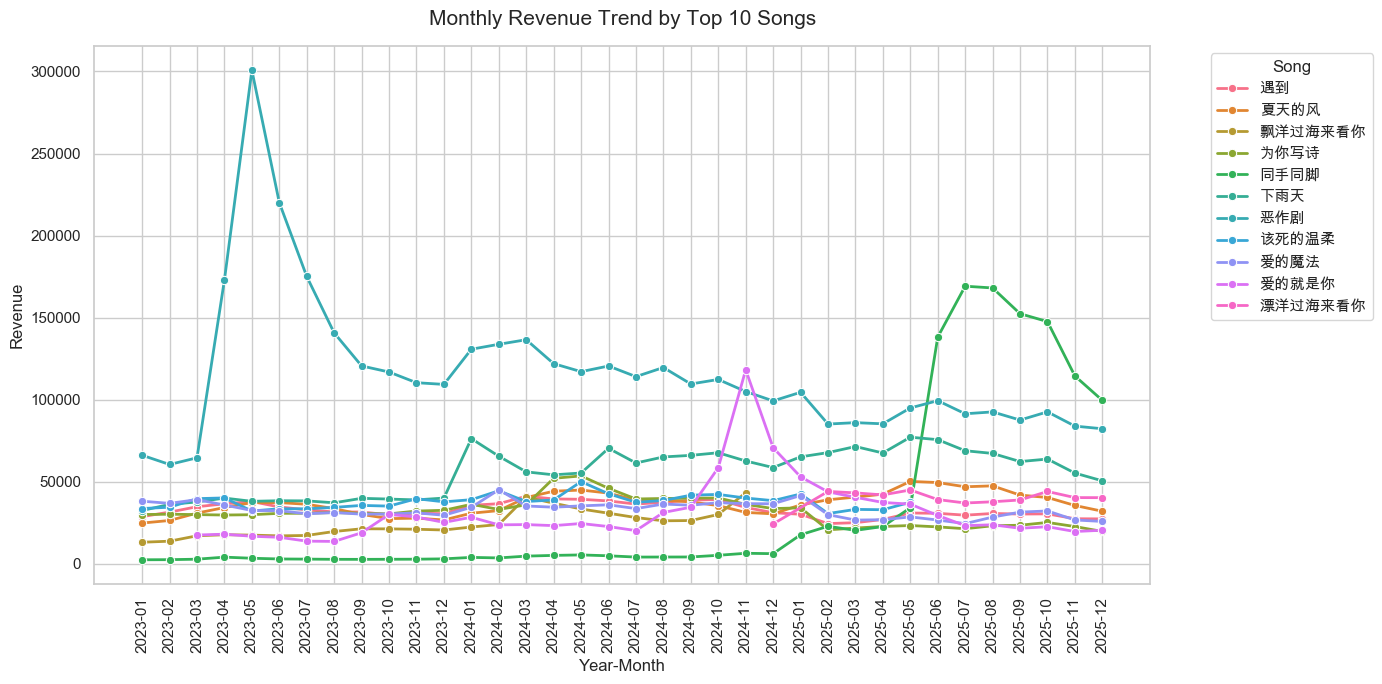

In [19]:
revenue_by_song_per_month = (
    df_filtered
    .groupby([ 'ISRC', 'YearMonth'])
    .agg(
        song=('standard_song', 'first'),
        revenue=('Revenue', 'sum')
    )
    .reset_index()
)
monthly_revenue_top_song = revenue_by_song_per_month[
    revenue_by_song_per_month['ISRC'].isin(top_song_list)
].sort_values('YearMonth')

plotting.plot_monthly_revenue_by_top_songs(monthly_revenue_top_song, TOP_N_SONGS)

## Revenue by Platform

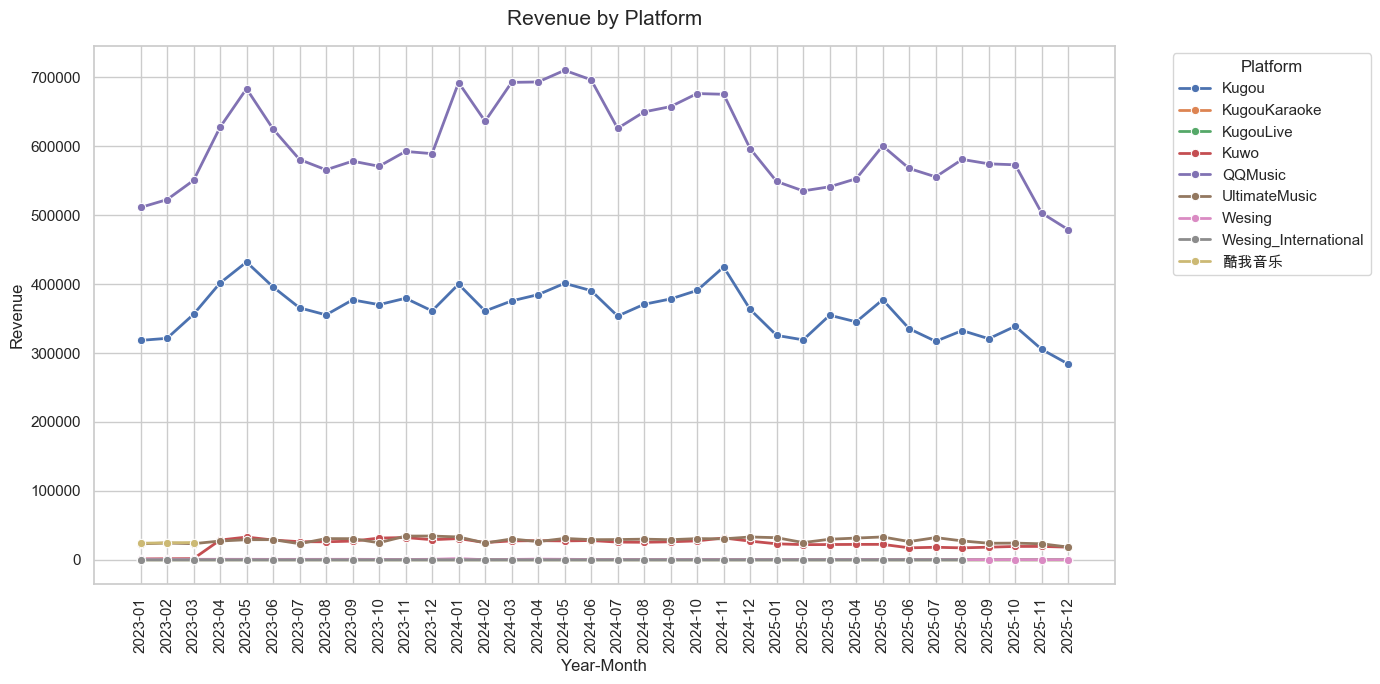

In [20]:
revenue_by_platform_per_month = (
    df_filtered
    .groupby(['ISRC', 'YearMonth', 'Platform'])
    .agg(revenue=('Revenue', 'sum'))
    .reset_index()
)
revenue_by_platform = (
    revenue_by_platform_per_month
    .groupby(['YearMonth', 'Platform'])
    .agg(revenue=('revenue', 'sum'))
    .reset_index()
)

plotting.plot_revenue_by_platform(revenue_by_platform)

In [21]:
revenue_by_platform['Platform'].value_counts()

Platform
Kugou                   36
KugouKaraoke            36
KugouLive               36
Kuwo                    36
QQMusic                 36
UltimateMusic           36
Wesing                  36
Wesing_International    32
酷我音乐                     3
Name: count, dtype: int64

## Generate Album Report & Plot Revenue by Album

Top 10 albums contribute to 91.73% of total revenue.


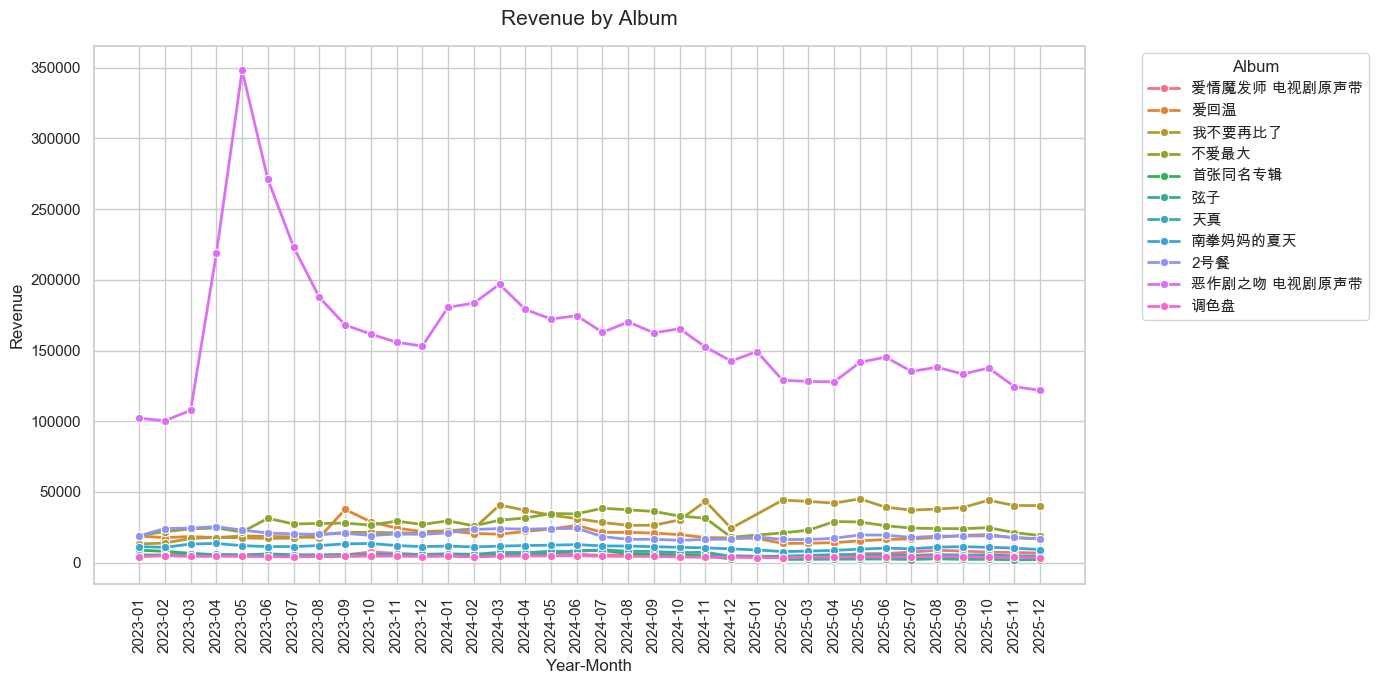

In [22]:
# Generate Excel report for Albums
# album_final = generate_album_report(df_filtered, OUTPUT_ALBUM_REPORT_PATH)
# display(album_final.head())

# Find top albums contribute to total revenue
revenue_by_album = (
    df_filtered
    .groupby(['UPC'])
    .agg(
        album=('Album', 'first'),
        revenue=('Revenue', 'sum')
    )
    .reset_index()
)
revenue_by_album = revenue_by_album.sort_values('revenue', ascending=False)
print(f"Top {TOP_N_ALBUMS} albums contribute to {revenue_by_album['revenue'].head(TOP_N_ALBUMS).sum()/revenue_by_album['revenue'].sum():.2%} of total revenue.")

# Plot monthly trend lines for the top albums
top_n_album_list = revenue_by_album['UPC'].head(TOP_N_ALBUMS).tolist()
revenue_by_album_per_month = (
    df_filtered
    .groupby(['UPC', 'YearMonth'])
    .agg(
        album=('Album', 'first'),
        revenue=('Revenue', 'sum')
    )
    .reset_index()
)
top_album_trend = revenue_by_album_per_month[
    revenue_by_album_per_month['UPC'].isin(top_n_album_list)
]
plotting.plot_revenue_by_album(top_album_trend)